# Erosão e Dilatação Morfológica (Manual + OpenCV)

Este notebook mostra, de forma **didática e comparativa**, como funcionam as operações morfológicas
**erosão** e **dilatação** em imagens binárias (0/255), usando:

- Implementação **manual** (funções do `utils.py`)
- Implementação equivalente do **OpenCV**

Ao final, você vai entender:
1. O papel do **elemento estruturante (SE)**  
2. Por que às vezes a *dilatação “parece erosão”* (dica: depende de quem é **objeto** e quem é **fundo**)  
3. Como o número de **iterações** muda o resultado


### Importações

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from pathlib import Path
import math

sys.path.append(str(Path().resolve().parent))

import utils as ut
plt.rcParams["figure.figsize"] = (10, 4)

### Leitura da imagem

In [20]:
IMG_PATH = Path("rio-janeiro.webp")

image = cv.imread(str(IMG_PATH), cv.IMREAD_COLOR)

if image is None:
    raise FileNotFoundError(f"Não consegui ler o arquivo: {IMG_PATH.resolve()}")

print("Imagem carregada com sucesso!", image.shape, image.dtype)

Imagem carregada com sucesso! (524, 640, 3) uint8


### Análise exploratória

In [3]:
ut.eda_image(image)

Largura em pixels: 1000
Altura em pixels: 1102
Quantidade de pixels: 1102000
Quantidade de elementos presentes na matriz: 3306000
Quantidade de canais: 3


### Conversão para tons de cinza

Aqui usamos a função do seu `utils.py` (`generate_gray_channel`), que faz a média simples dos canais:
\[
gray = \frac{B + G + R}{3}
\]

> O OpenCV tem `cv.cvtColor(..., cv.COLOR_BGR2GRAY)`, mas vamos seguir a implementação manual do trabalho.


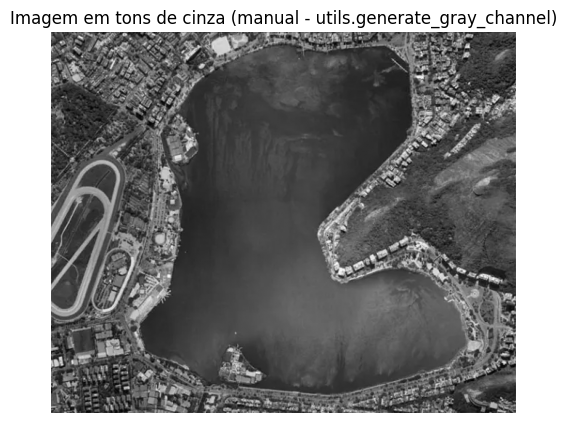

Gray: (524, 640) uint8 min/max: 0 254


In [21]:
gray = ut.generate_gray_channel(image)

plt.figure(figsize=(6, 5))
plt.imshow(gray, cmap="gray")
plt.title("Imagem em tons de cinza (manual - utils.generate_gray_channel)")
plt.axis("off")
plt.show()

print("Gray:", gray.shape, gray.dtype, "min/max:", int(gray.min()), int(gray.max()))

### Histograma (tons de cinza)

O histograma ajuda a escolher um limiar (threshold) para binarização.
Vamos usar `ut.histograma` e depois plotar.

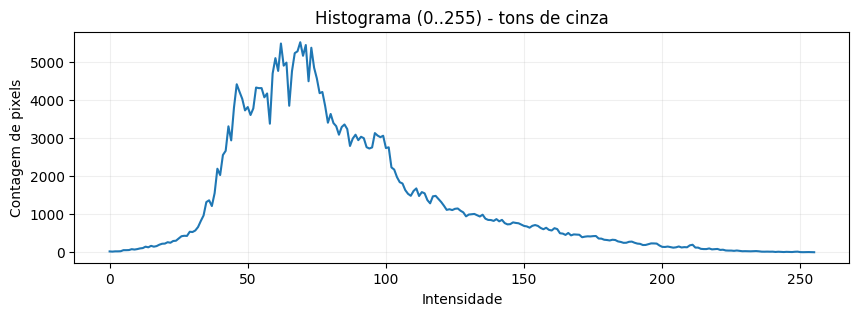

In [22]:
hist = ut.histograma(gray)

plt.figure(figsize=(10, 3))
plt.plot(hist)
plt.title("Histograma (0..255) - tons de cinza")
plt.xlabel("Intensidade")
plt.ylabel("Contagem de pixels")
plt.grid(True, alpha=0.2)
plt.show()

### Binarização + escolha de **objeto** e **fundo**

Operações morfológicas binárias normalmente assumem:

- **Objeto (foreground)**: 255 (branco)
- **Fundo (background)**: 0 (preto)

Se você trabalhar com o contrário (objeto preto em fundo branco), é comum acontecer o efeito de
“**dilatação parecer erosão**”, porque você está, na prática, expandindo o fundo (branco) e “comendo” o objeto (preto).

Abaixo vamos:
1. Binarizar com Otsu (automático)
2. Garantir que o **objeto fique branco (255)** para usar as funções do `utils.py`

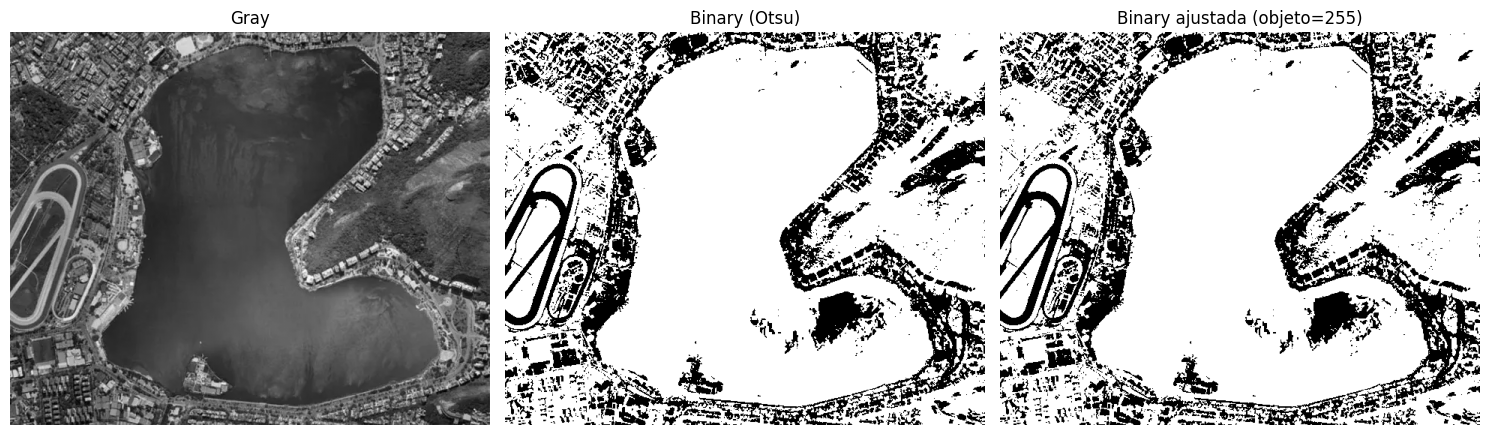

mean(binary_raw) = 194.35690004770993 | mean(binary) = 194.35690004770993


In [23]:
# Otsu escolhe automaticamente o limiar (bom ponto de partida)
_, binary_raw = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Heurística simples: se a imagem binária ficou "muito branca", provavelmente o fundo é branco
# e o objeto é preto -> invertendo, garantimos objeto branco em fundo preto.
if np.mean(binary_raw) > 127:
    binary = 255 - binary_raw
else:
    binary = binary_raw.copy()
    
binary = cv.bitwise_not(binary) 

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gray, cmap="gray"); ax[0].set_title("Gray"); ax[0].axis("off")
ax[1].imshow(binary_raw, cmap="gray"); ax[1].set_title("Binary (Otsu)"); ax[1].axis("off")
ax[2].imshow(binary, cmap="gray"); ax[2].set_title("Binary ajustada (objeto=255)"); ax[2].axis("off")
plt.tight_layout()
plt.show()

print("mean(binary_raw) =", float(np.mean(binary_raw)), "| mean(binary) =", float(np.mean(binary)))

### Elemento Estruturante (SE)

O **elemento estruturante** é uma pequena máscara (ex.: 3×3) que “varre” a imagem.

- **Erosão:** tende a **reduzir** o objeto (remove pixels de borda)
- **Dilatação:** tende a **aumentar** o objeto (adiciona pixels na borda)

Vamos testar SEs padrões do OpenCV (RETÂNGULO, CRUZ, ELIPSE).

In [14]:
ses = {
    "RECT_3x3": cv.getStructuringElement(cv.MORPH_RECT, (3, 3)),
    "CROSS_3x3": cv.getStructuringElement(cv.MORPH_CROSS, (3, 3)),
    "ELLIPSE_3x3": cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3)),
}

for name, se in ses.items():
    print(name)
    print(se.astype(int), "\n")

RECT_3x3
[[1 1 1]
 [1 1 1]
 [1 1 1]] 

CROSS_3x3
[[0 1 0]
 [1 1 1]
 [0 1 0]] 

ELLIPSE_3x3
[[0 1 0]
 [1 1 1]
 [0 1 0]] 



#### Erosão (manual vs OpenCV)

Definição intuitiva (binário com objeto=255):
- Um pixel só continua **branco (255)** se **toda a vizinhança** definida pelo SE também for branca.

Isso “encolhe” o objeto, removendo ruídos brancos pequenos e afinando estruturas.

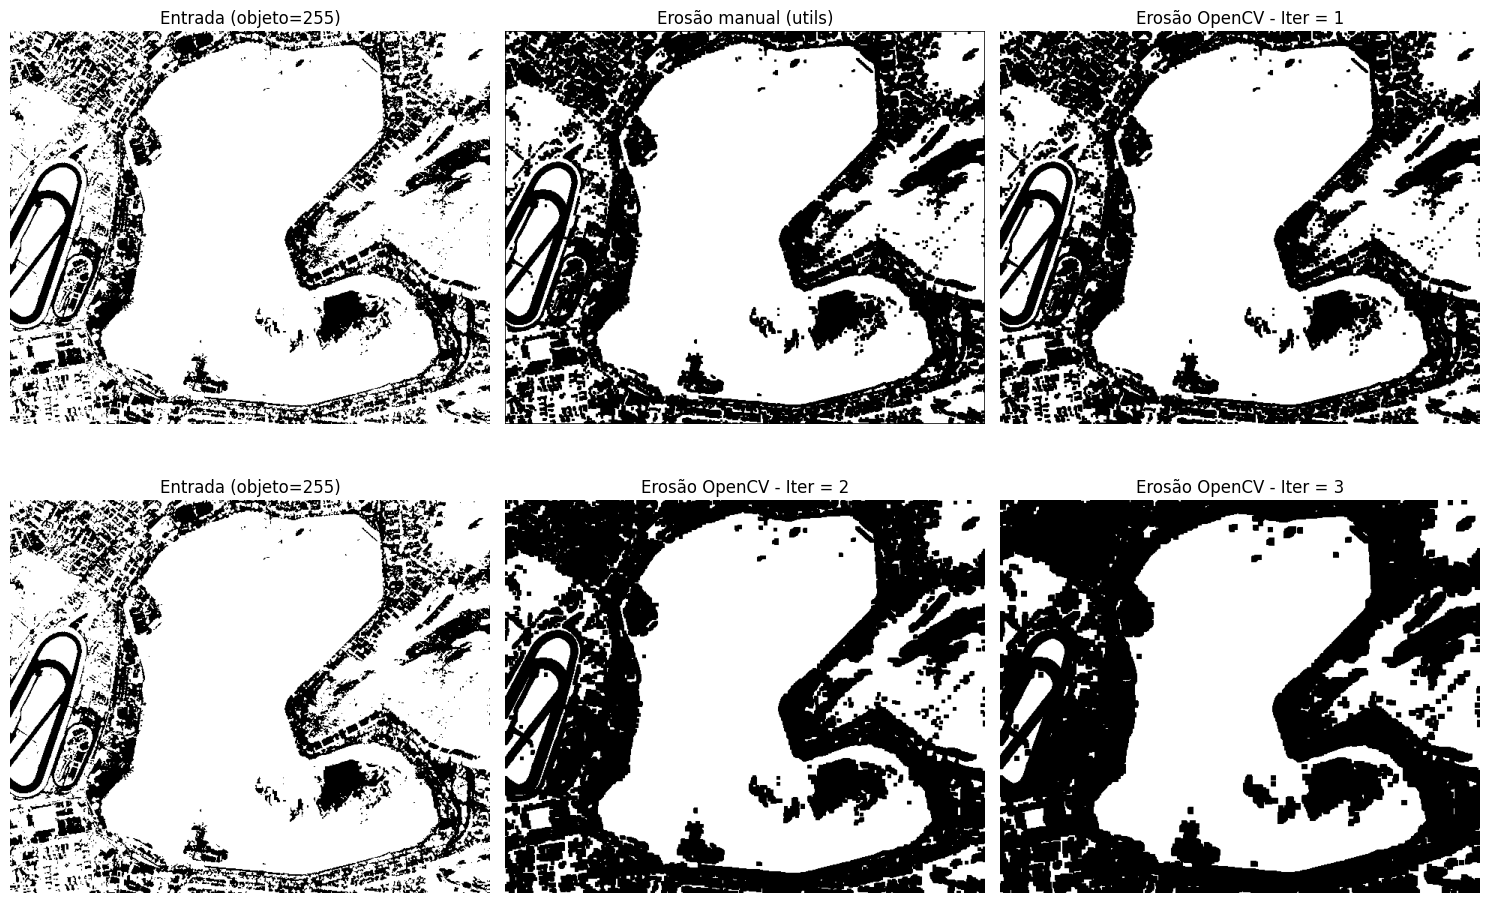

Diferença absoluta total (manual vs cv): 290190


In [24]:
se3 = np.ones((3, 3), dtype=np.uint8)

eros_manual = ut.manual_erosion(binary, se3, iterations=1)
eros_cv = cv.erode(binary, se3, iterations=1)
eros_cv_2 = cv.erode(binary, se3, iterations=2)
eros_cv_3 = cv.erode(binary, se3, iterations=3)

# Mude para 2 linhas, 3 colunas
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

# Primeira linha
ax[0, 0].imshow(binary, cmap="gray"); ax[0, 0].set_title("Entrada (objeto=255)"); ax[0, 0].axis("off")
ax[0, 1].imshow(eros_manual, cmap="gray"); ax[0, 1].set_title("Erosão manual (utils)"); ax[0, 1].axis("off")
ax[0, 2].imshow(eros_cv, cmap="gray"); ax[0, 2].set_title("Erosão OpenCV - Iter = 1"); ax[0, 2].axis("off")

# Segunda linha
ax[1, 0].imshow(binary, cmap="gray"); ax[1, 0].set_title("Entrada (objeto=255)"); ax[1, 0].axis("off")
ax[1, 1].imshow(eros_cv_2, cmap="gray"); ax[1, 1].set_title("Erosão OpenCV - Iter = 2"); ax[1, 1].axis("off")
ax[1, 2].imshow(eros_cv_3, cmap="gray"); ax[1, 2].set_title("Erosão OpenCV - Iter = 3"); ax[1, 2].axis("off")

plt.tight_layout()
plt.show()

print("Diferença absoluta total (manual vs cv):", int(np.sum(np.abs(eros_manual.astype(int) - eros_cv.astype(int)))))

#### Dilatação (manual vs OpenCV)

Definição intuitiva (binário com objeto=255):
- Um pixel vira **branco (255)** se existir **pelo menos um branco** sob o SE.

Isso “engrossa” o objeto e pode preencher pequenas falhas.

> Observação: se a sua `ut.manual_dilation` estiver dando erro com `background_value`,
> veja o patch no final da conversa (é um bug simples).

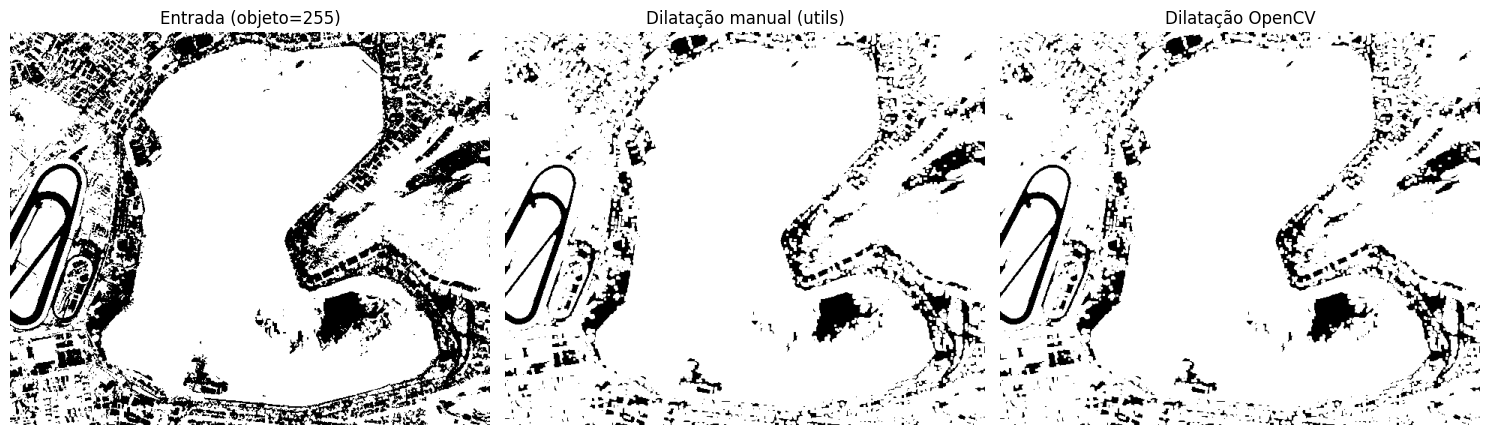

Diferença absoluta total (manual vs cv): 0


In [25]:
dil_manual = ut.manual_dilation(binary, se3, iterations=1)
dil_cv = cv.dilate(binary, se3, iterations=1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(binary, cmap="gray"); ax[0].set_title("Entrada (objeto=255)"); ax[0].axis("off")
ax[1].imshow(dil_manual, cmap="gray"); ax[1].set_title("Dilatação manual (utils)"); ax[1].axis("off")
ax[2].imshow(dil_cv, cmap="gray"); ax[2].set_title("Dilatação OpenCV"); ax[2].axis("off")
plt.tight_layout()
plt.show()

print("Diferença absoluta total (manual vs cv):", int(np.sum(np.abs(dil_manual.astype(int) - dil_cv.astype(int)))))


#### Número de iterações: o que muda?

- Mais iterações de **erosão**: objeto vai ficando menor (pode até sumir)
- Mais iterações de **dilatação**: objeto cresce e pode “grudar” em objetos próximos

Vamos comparar 1, 2 e 3 iterações para SE 3×3.


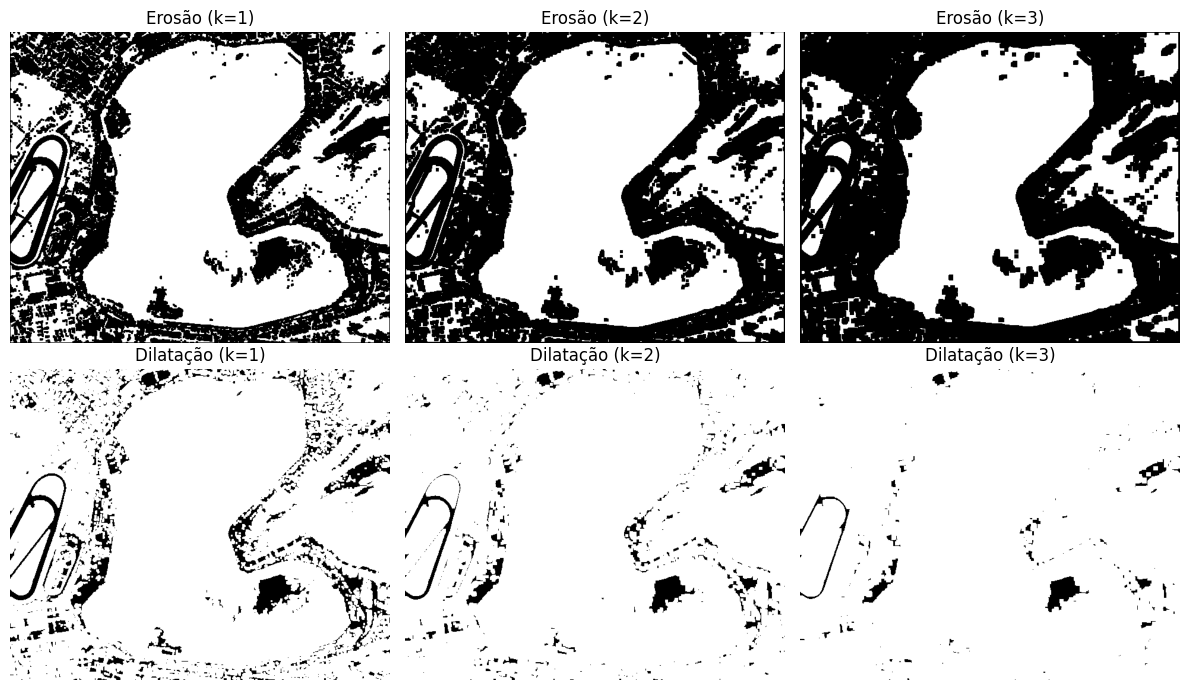

In [26]:
iters = [1, 2, 3]

eros_list = [ut.manual_erosion(binary, se3, iterations=k) for k in iters]
dil_list  = [ut.manual_dilation(binary, se3, iterations=k) for k in iters]

fig, ax = plt.subplots(2, len(iters), figsize=(4*len(iters), 7))

for i,k in enumerate(iters):
    ax[0, i].imshow(eros_list[i], cmap="gray")
    ax[0, i].set_title(f"Erosão (k={k})")
    ax[0, i].axis("off")

    ax[1, i].imshow(dil_list[i], cmap="gray")
    ax[1, i].set_title(f"Dilatação (k={k})")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()
